In [1]:
import numpy as np

# HANKEL MATRIX GENERATION

from hasvd.utils.matrix import array_to_hankel, fid_signal_sequence, lrf_sequence

seed = 42               # RNG seed

M = 4                  # Num. of row blocks
N = 5                 # Num. of column blocks
(m,n) = (300,300)      # Block size
r = 150                  # Desired rank

matrix_rng=np.random.Generator(np.random.MT19937(seed))

A_array = fid_signal_sequence(r,M*m+N*n-1,matrix_rng)

A = array_to_hankel(A_array,(M*m,N*n))

print("Generated random Hankel matrix...")
print("Prescribed rank:", r)
print("Matrix rank sanity check:", np.linalg.matrix_rank(A))
print("Matrix shape:", A.shape)
print("Block shape:", "(", m, ",", n, ")")
print("Block partitions:", "(", M, ",", N, ")\n")

Generated random Hankel matrix...
Prescribed rank: 150
Matrix rank sanity check: 19
Matrix shape: (1200, 1500)
Block shape: ( 300 , 300 )
Block partitions: ( 4 , 5 )



We follow the same steps in parameter assignment.

In [2]:
# PARAMETERS

tol = 1e-8            # Prescribe tolerance and control parameter
omega = 0.1


# STANDARD SVD COMPARISON

from hasvd.utils.svd import svd_with_tol
from time import time

print("\u0332".join("LAPACK gesdd"))
# SVD of the whole matrix
start = time()
U, Etrue, Vh = svd_with_tol(
    A,
    full_matrices=False
    ,truncate_tol=tol
)
duration = time()-start
print("Error:", np.linalg.norm(A - U @ np.diag(Etrue) @ Vh))
print("Runtime:", duration," seconds")
print("Rank of U*S*Vt:", np.linalg.matrix_rank(U @ np.diag(Etrue) @ Vh), "\n")

L̲A̲P̲A̲C̲K̲ ̲g̲e̲s̲d̲d
Error: 8.61363649618618e-09
Runtime: 1.330200433731079  seconds
Rank of U*S*Vt: 14 



Again tree construction.

In [3]:
# TREE CONSTRUCTION

from hasvd.utils.trees import tlbd_dist_hasvd_tree, tlbd_inc_hasvd_tree, assert_shape_consistency

outer_direction = 1     # Direction of the root-level aggregation
tree_choice = 0         # Choice of tree: 0 distributed, 1 incremental

match outer_direction:
    case 0:
        num_outer_slices=N
        num_inner_slices=M
    case 1:
        num_outer_slices=M
        num_inner_slices=N

trees = [tlbd_dist_hasvd_tree(num_outer_slices,num_inner_slices,outer_direction,(m,n), 'hankel'),tlbd_inc_hasvd_tree(num_outer_slices,num_inner_slices,outer_direction,(m,n))]

for tree in trees:
    assert_shape_consistency(tree)

tree = trees[tree_choice]
print(tree) # Print to check shape of tree if necessary.

r r [1200x1500]
+-c 20 [300x1500]
| +-l 0 [300x300]
| +-l 1 [300x300]
| +-l 2 [300x300]
| +-l 3 [300x300]
| +-l 4 [300x300]
+-c 21 [300x1500]
| +-l 5 [300x300]
| +-l 6 [300x300]
| +-l 7 [300x300]
| +-l 8 [300x300]
| +-l 9 [300x300]
+-c 22 [300x1500]
| +-l 10 [300x300]
| +-l 11 [300x300]
| +-l 12 [300x300]
| +-l 13 [300x300]
| +-l 14 [300x300]
+-c 23 [300x1500]
  +-l 15 [300x300]
  +-l 16 [300x300]
  +-l 17 [300x300]
  +-l 18 [300x300]
  +-l 19 [300x300]


We now build a different block-to-leaf map to connect the Hankel arrays from blocks to the tree. 

In [4]:
from hasvd.utils.trees import tlbd_hankelarray_btl_map,branch_node_count, non_leaf_count
from hasvd.utils.errors import tight_error,naive_error

from hasvd.utils.svd import hasvd,simple_cache_map

btl_map = tlbd_hankelarray_btl_map(A_array,M,N,m,n,outer_direction)   # Makes a map to block of a node
error_choice = 0                                            # Choice of error_prescription: 0 naive, 1 tight

nodal_errors = [lambda node : tight_error(
            node,
            tol,
            omega,
            branch_node_count(tree),
        ),lambda node : naive_error(
            node,
            tol,
            omega,
            non_leaf_count(tree),
        )]
nodal_error=nodal_errors[error_choice]

print("\u0332".join("HASVD"))
start = time()
U, E, Vh, rank_dict = hasvd(tree,btl_map,nodal_error, track_ranks=True)
duration = time()-start
print("Error:", np.linalg.norm(A - U @ np.diag(E) @ Vh))
print("Runtime:", duration," seconds")

print("\u0332".join("pruned HASVD"))
start = time()
U, E, Vh, rank_dict = hasvd(tree,btl_map,nodal_error, track_ranks=True, cache_map=simple_cache_map)
duration = time()-start
print("Error:", np.linalg.norm(A - U @ np.diag(E) @ Vh))
print("Runtime:", duration," seconds")
print("Rank of U*S*Vt:", np.linalg.matrix_rank(U @ np.diag(E) @ Vh), "\n")

H̲A̲S̲V̲D
Error: 1.2901318074483666e-09
Runtime: 0.6058528423309326  seconds
p̲r̲u̲n̲e̲d̲ ̲H̲A̲S̲V̲D
Error: 1.2901318074483666e-09
Runtime: 0.2639656066894531  seconds
Rank of U*S*Vt: 15 



Use `plot_rank_graph` to analyze the rank truncation in nxGraph or `print_rank_graph` for terminal.

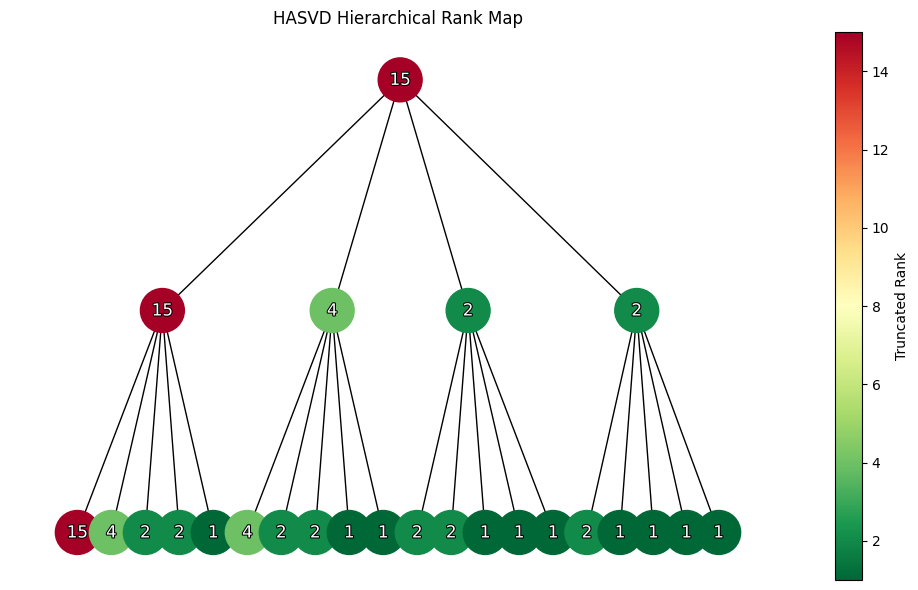

r (Rank: 15)
    20 (Rank: 15)
        0 (Rank: 15)
        1 (Rank: 4)
        2 (Rank: 2)
        3 (Rank: 2)
        4 (Rank: 1)
    21 (Rank: 4)
        5 (Rank: 4)
        6 (Rank: 2)
        7 (Rank: 2)
        8 (Rank: 1)
        9 (Rank: 1)
    22 (Rank: 2)
        10 (Rank: 2)
        11 (Rank: 2)
        12 (Rank: 1)
        13 (Rank: 1)
        14 (Rank: 1)
    23 (Rank: 2)
        15 (Rank: 2)
        16 (Rank: 1)
        17 (Rank: 1)
        18 (Rank: 1)
        19 (Rank: 1)


In [ ]:
from hasvd.utils.trees import plot_rank_graph, print_rank_graph

plot_rank_graph(tree,rank_dict)

print_rank_graph(tree,rank_dict)

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\e'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_80614/2250407907.py:8: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("$\sigma_i$")
/tmp/ipykernel_80614/2250407907.py:10: SyntaxWarning: invalid escape sequence '\e'
  plt.title("Tolerance $\epsilon*$= "+str(tol))


(0.0, 20.0)

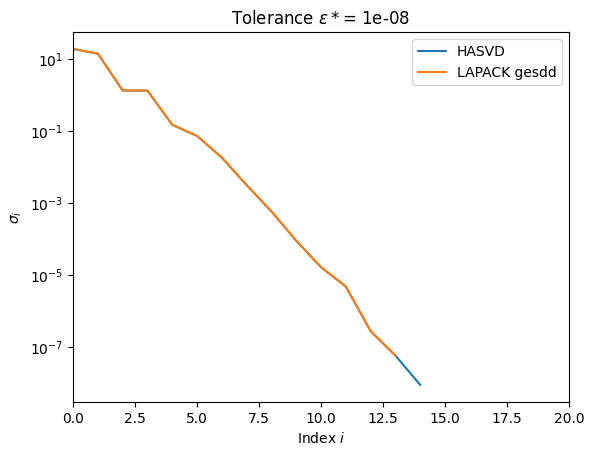

In [13]:
import matplotlib.pyplot as plt

fig=plt.figure()
plt.plot(E, label="HASVD")
plt.plot(Etrue, label="LAPACK gesdd")

plt.yscale('log')
plt.ylabel("$\sigma_i$")
plt.xlabel("Index $i$")
plt.title("Tolerance $\epsilon*$= "+str(tol))

plt.legend()

plt.xlim([0,20])